# 03 — PiNet Stage A Training

**FusionCore v1 — Phase Ph-v1.3**

This notebook trains PiNet (instantiated in Notebook 02 with deterministic
seed 42) on the Internal Train partition under the composite loss specified
in `v1CLAUDE.md` §5. Per-epoch checkpoints are persisted; early stopping
fires on Internal Validation NASA Asymmetric Score with patience 15. Stage A
is the primary v₁ training experiment — its output is the input to Ph-v1.4
headline evaluation against the v0 XGBoost baseline.

### Reading order at session start

1. `../MICHELE-CLAUDE.md` — personal profile and workflow.
2. `../v1CLAUDE.md` — v1 project constitution; particularly §5 (loss),
   §6 (fixed hyperparameters), §7 (batch composition), §9 (Critical-recall
   safety gate).
3. `../CLAUDE.md` (legacy root) — frozen v0 invariants.
4. `../reports/FusionCore_v1_Master_Roadmap.pdf` — authoritative spec.

### Phase scope

| Phase | Description | Acceptance gate |
|---|---|---|
| **Ph-v1.3** | Stage A training: composite loss, AdamW, fixed hyperparameters, per-epoch checkpoints, early stopping on Internal Val NASA score | Programmatic gate (12 checks) |

### Composite loss (v1CLAUDE.md §5)

$$L_{\text{total}} = \sum_i w_{r(i)} \big( L_{\text{RUL},i} + \lambda_{\text{class}} \cdot L_{\text{CE},i} \big)$$

with $\lambda_{\text{class}} = 0.3$ frozen, $L_{\text{RUL}}$ the NASA
asymmetric score with $\{13, 10\}$ exponents, $L_{\text{CE}}$ the
class-weighted three-class cross-entropy, and $w_r$ the per-window
inverse-frequency regime weight from Ph-v1.1.

### Outputs (under `v1/outputs/`)

| File | Purpose |
|---|---|
| `phase_v1_3_pinet_best.pt` | Best-epoch state-dict (lowest Internal Val NASA score) — input to Ph-v1.4 |
| `phase_v1_3_pinet_last.pt` | Final-epoch state-dict (for resume) |
| `phase_v1_3_training_history.json` | Per-epoch metrics (loss, RMSE, NASA, P/R/F₂ per class) |
| `phase_v1_3_loss_curves.png` | Training and validation loss curves |
| `phase_v1_3_critical_metrics.png` | Critical-class precision / recall / F₂ over epochs |

### References

- Bai, S., Kolter, J. Z. and Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. *arXiv 1803.01271*.
- Saxena, A. *et al.* (2008). Damage propagation modeling for aircraft engine run-to-failure simulation. *PHM 2008*.
- Heimes, F. O. (2008). Recurrent neural networks for RUL estimation. *PHM 2008*.
- Loshchilov, I. and Hutter, F. (2019). Decoupled weight decay regularisation. *ICLR 2019* (AdamW).
- Li, X., Ding, Q. and Sun, J. Q. (2018). Remaining useful life estimation in prognostics using deep convolution neural networks. *Reliability Engineering & System Safety* 172, 1–11.

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================

import sys, os, json, time, math, warnings, pickle, copy
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings("ignore")

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"numpy    : {np.__version__}")

Python   : 3.13.13
PyTorch  : 2.11.0
numpy    : 2.4.4


## Cell 2 — FusionCore Palette and Matplotlib Configuration

In [2]:
# ============================================================================
# Cell 2 — FusionCore Palette and Matplotlib Configuration
# ============================================================================

FC_DARK_BLUE  = "#0D1B2A"
FC_NAVY       = "#1B3A5C"
FC_ORANGE     = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"
FC_STEEL      = "#4A6274"
FC_CHARCOAL   = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]

plt.rcParams.update({
    "figure.figsize":   (14, 5),  "figure.dpi":  110,
    "savefig.dpi":      300,      "savefig.bbox": "tight",
    "font.family":      "serif",  "font.size":   11,
    "axes.titlesize":   13,       "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   FC_CHARCOAL, "axes.labelcolor": FC_CHARCOAL,
    "axes.spines.top":  False,    "axes.spines.right": False,
    "axes.prop_cycle":  mpl.cycler(color=FC_PALETTE),
    "xtick.color":      FC_CHARCOAL, "ytick.color": FC_CHARCOAL,
    "legend.fontsize":  9,        "legend.framealpha": 0.9,
    "grid.color":       FC_LIGHT_GREY, "grid.alpha": 0.6, "grid.linestyle": ":",
})
print("Visualisation configured.")

Visualisation configured.


## Cell 3 — Project Constants and Frozen Hyperparameters

In [3]:
# ============================================================================
# Cell 3 — Project Constants, Paths, Seeds, Device, and Hyperparameters
# ============================================================================

PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"
V1_OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOM_STATE)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Architecture (must match Notebook 02 — Ph-v1.2).
W                 = 30
N_FEATURES        = 89
N_PHYSICS_TOKENS  = 11
TCN_HIDDEN        = 64
TCN_KERNEL        = 3
TCN_DILATIONS     = [1, 2, 4, 8, 16]
TCN_DROPOUT       = 0.15
EMBED_DIM         = 128
PHYS_HIDDEN       = 50
PHYS_OUT          = 32
HEAD_HIDDEN       = 64
N_RISK_CLASSES    = 3
RUL_CAP           = 125

# Training (frozen — v1CLAUDE.md §6).
BATCH_SIZE        = 64
LEARNING_RATE     = 1e-3
WEIGHT_DECAY      = 1e-4
MAX_EPOCHS        = 80
EARLY_STOP_PATIENCE = 15
LAMBDA_CLASS      = 0.3

# Loss configuration.
NASA_LATE_EXP     = 10.0     # late-prediction exponent (worse — exponential)
NASA_EARLY_EXP    = 13.0     # early-prediction exponent (better — slower exponential)

# Healthy / Warning / Critical risk-band thresholds.
HEALTHY_TH        = 80
WARNING_TH        = 30

print(f"Device              : {DEVICE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Max epochs          : {MAX_EPOCHS}")
print(f"Early-stop patience : {EARLY_STOP_PATIENCE}")
print(f"λ_class (frozen)    : {LAMBDA_CLASS}")

Device              : mps
Batch size          : 64
Learning rate       : 0.001
Max epochs          : 80
Early-stop patience : 15
λ_class (frozen)    : 0.3


---

## Part A — Load Ph-v1.1 Windowed Tensors and Build DataLoaders

Re-load `windows_train.pt` and `windows_val.pt` from Ph-v1.1. Build a
stratified-sampler train DataLoader and a natural-distribution validation
DataLoader. The Dataset class is re-defined inline for self-containment;
its contract matches Notebook 01 §4.7.

In [4]:
# ============================================================================
# Cell 4 — Load Windowed Tensors from Ph-v1.1
# ============================================================================

train_bundle = torch.load(V1_OUT / "windows_train.pt", weights_only=False)
val_bundle   = torch.load(V1_OUT / "windows_val.pt",   weights_only=False)

Xw_train   = train_bundle["Xw"]
mask_train = train_bundle["mask"]
rul_train  = train_bundle["rul"]
rb_train   = train_bundle["risk_band"]
rw_train   = train_bundle["regime_w"]
phys_idx   = train_bundle["phys_idx"]
class_w    = train_bundle["class_w"]
v1_features = train_bundle["feature_names"]
phys_names  = train_bundle["physics_token_names"]

Xw_val     = val_bundle["Xw"]
mask_val   = val_bundle["mask"]
rul_val    = val_bundle["rul"]
rb_val     = val_bundle["risk_band"]
rw_val     = val_bundle["regime_w"]

print(f"Train windows : Xw {tuple(Xw_train.shape)}    rul {tuple(rul_train.shape)}    rb {tuple(rb_train.shape)}")
print(f"Val   windows : Xw {tuple(Xw_val.shape)}      rul {tuple(rul_val.shape)}      rb {tuple(rb_val.shape)}")
print(f"Class weights : {class_w.tolist()}")
print(f"Physics tokens: {phys_names}")

Train windows : Xw (129331, 30, 89)    rul (129331,)    rb (129331,)
Val   windows : Xw (31028, 30, 89)      rul (31028,)      rb (31028,)
Class weights : [0.5133954882621765, 1.5206466913223267, 2.5344111919403076]
Physics tokens: ['s4', 's7', 's9', 'CPR', 'eta_c', 's4_cumfatigue', 's9_cumfatigue', 's7_cumfatigue', 'hazard_score', 'fault_mode_family']


In [5]:
# ============================================================================
# Cell 5 — FusionCoreWindowDataset (re-defined inline; same contract as Notebook 01)
# ============================================================================

class FusionCoreWindowDataset(Dataset):
    def __init__(self, Xw, mask, rul, rb, regime_w, phys_idx):
        self.Xw       = Xw
        self.mask     = mask
        self.rul      = torch.as_tensor(rul, dtype=torch.float32)
        self.rb       = torch.as_tensor(rb,  dtype=torch.long)
        self.regime_w = torch.as_tensor(regime_w, dtype=torch.float32)
        self.phys_idx = torch.as_tensor(phys_idx, dtype=torch.long)

    def __len__(self):
        return self.Xw.shape[0]

    def __getitem__(self, i):
        x_tcn  = self.Xw[i]
        x_phys = x_tcn.index_select(dim=-1, index=self.phys_idx)
        return {
            "x_tcn":     x_tcn,
            "x_phys":    x_phys,
            "mask":      self.mask[i],
            "rul":       self.rul[i],
            "risk_band": self.rb[i],
            "regime_w":  self.regime_w[i],
        }

ds_train = FusionCoreWindowDataset(Xw_train, mask_train, rul_train, rb_train, rw_train, phys_idx)
ds_val   = FusionCoreWindowDataset(Xw_val,   mask_val,   rul_val,   rb_val,   rw_val,   phys_idx)
print(f"Datasets: train {len(ds_train):,}    val {len(ds_val):,}")

Datasets: train 129,331    val 31,028


In [6]:
# ============================================================================
# Cell 6 — DataLoaders (stratified train, natural-distribution val)
# ============================================================================

# Stratified sampler — v1CLAUDE.md §7 batch composition (45/27.5/27.5).
def stratified_sampler(rb: np.ndarray, target=(0.45, 0.275, 0.275)) -> WeightedRandomSampler:
    rb_np = rb if isinstance(rb, np.ndarray) else rb.numpy()
    counts = np.bincount(rb_np, minlength=3).clip(min=1)
    inv = np.array([target[c] / counts[c] for c in range(3)], dtype=np.float64)
    weights = inv[rb_np]
    return WeightedRandomSampler(weights=torch.from_numpy(weights),
                                 num_samples=len(rb_np), replacement=True,
                                 generator=torch.Generator().manual_seed(RANDOM_STATE))

sampler_train = stratified_sampler(rb_train.numpy() if isinstance(rb_train, torch.Tensor) else rb_train)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler_train,
                      num_workers=0, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, drop_last=False)

print(f"Train batches per epoch : {len(dl_train):,}")
print(f"Val   batches per epoch : {len(dl_val):,}")

Train batches per epoch : 2,020
Val   batches per epoch : 485


---

## Part B — Re-define PiNet (self-contained)

The PiNet class is duplicated here from Notebook 02 to keep this notebook
runnable independently. The architecture must be byte-identical to Notebook
02 so the Ph-v1.2 initial state-dict loads cleanly.

In [7]:
# ============================================================================
# Cell 7 — CausalConv1d and TemporalBlock
# ============================================================================

class CausalConv1d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(F.pad(x, (self.left_pad, 0)))


class TemporalBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int,
                 dilation: int, dropout: float):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch
                         else nn.Identity())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        h = self.conv1(x)
        h = self.norm1(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h)
        h = self.norm2(h.transpose(1, 2)).transpose(1, 2)
        h = h + residual
        h = F.relu(h); h = self.dropout(h)
        return h
print("CausalConv1d, TemporalBlock defined.")

CausalConv1d, TemporalBlock defined.


In [8]:
# ============================================================================
# Cell 8 — TCN, PhysicsMLP, FusionMLP, RULHead, RiskBandHead
# ============================================================================

class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x.transpose(1, 2)).transpose(1, 2)


class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN),
            nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT),
            nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys: torch.Tensor, regime_w: torch.Tensor) -> torch.Tensor:
        x_anchor = x_phys[:, -1, :]
        return self.net(torch.cat([x_anchor, regime_w.unsqueeze(-1)], dim=-1))


class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN * 2 + PHYS_OUT
        h = (ind + EMBED_DIM) // 2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
            nn.Linear(HEAD_HIDDEN, 1),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
            nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
print("TCN, PhysicsMLP, FusionMLP, RULHead, RiskBandHead defined.")

TCN, PhysicsMLP, FusionMLP, RULHead, RiskBandHead defined.


In [9]:
# ============================================================================
# Cell 9 — PiNet (two-branch assembly)
# ============================================================================

class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn       = TCN()
        self.physics   = PhysicsMLP()
        self.fusion    = FusionMLP()
        self.rul_head  = RULHead()
        self.risk_head = RiskBandHead()

    @staticmethod
    def _masked_mean(h: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        m = mask.float().unsqueeze(-1)
        return (h * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)

    def forward(self,
                x_tcn: torch.Tensor,
                x_phys: torch.Tensor,
                mask: torch.Tensor,
                regime_w: torch.Tensor) -> Dict[str, torch.Tensor]:
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        fused    = torch.cat([tcn_out, phys_out], dim=-1)
        embed    = self.fusion(fused)
        return {
            "rul_pred":    self.rul_head(embed),
            "risk_logits": self.risk_head(embed),
            "embed":       embed,
        }
print("PiNet defined.")

PiNet defined.


In [10]:
# ============================================================================
# Cell 10 — Instantiate PiNet and Load Ph-v1.2 Initial State-Dict
# ============================================================================

pinet = PiNet().to(DEVICE)
init_state = torch.load(V1_OUT / "phase_v1_2_pinet_init.pt",
                         map_location=DEVICE, weights_only=True)
pinet.load_state_dict(init_state)
n_params = sum(p.numel() for p in pinet.parameters())
print(f"PiNet instantiated on {DEVICE}")
print(f"Parameters: {n_params:,}")
print(f"Loaded initial state from phase_v1_2_pinet_init.pt")

PiNet instantiated on mps
Parameters: 196,816
Loaded initial state from phase_v1_2_pinet_init.pt


---

## Part C — Loss Functions

### NASA Asymmetric Score (Saxena *et al.* 2008)

$$s_i = \begin{cases} \exp(-d_i / 13) - 1 & \text{if } d_i < 0 \\ \exp(d_i / 10) - 1 & \text{if } d_i \geq 0 \end{cases}$$

where $d_i = \hat{y}_i - y_i$. Late predictions ($d \geq 0$) carry the
faster-growing exponent; early predictions are penalised more leniently.
This encodes the aviation-safety doctrine that a missed failure is
categorically worse than an unnecessary inspection. The piecewise
exponential is differentiable; we clamp $d$ to $[-R_{\text{cap}},
R_{\text{cap}}]$ for numerical stability under float32 MPS.

### Composite loss (v1CLAUDE.md §5)

$$L_{\text{total}} = \frac{1}{B}\sum_{i=1}^{B} w_{r(i)}\big( L_{\text{RUL},i} + 0.3 \cdot L_{\text{CE},i} \big)$$

where $L_{\text{CE}}$ is class-weighted cross-entropy with weights frozen
from Internal Train (Ph-v1.1) and $w_r$ is the per-window inverse-frequency
regime weight. The mean over the batch is the conventional reduction; the
two regularisers (regime weighting outside, class weighting inside CE)
remain orthogonal and additive in expectation.

In [11]:
# ============================================================================
# Cell 11 — NASA Asymmetric Loss (per-row, then per-batch reduction)
# ============================================================================

def nasa_asymmetric_per_row(rul_pred: torch.Tensor,
                            rul_true: torch.Tensor,
                            late_exp: float = NASA_LATE_EXP,
                            early_exp: float = NASA_EARLY_EXP,
                            cap: float = float(RUL_CAP)) -> torch.Tensor:
    """Per-row NASA asymmetric score.
    d = rul_pred - rul_true
    d >= 0  -> late prediction  -> exp(d / late_exp)  - 1   (steeper)
    d <  0  -> early prediction -> exp(-d / early_exp) - 1  (gentler)
    """
    d = (rul_pred - rul_true).clamp(min=-cap, max=cap)
    score_late  = torch.exp(d / late_exp) - 1.0
    score_early = torch.exp(-d / early_exp) - 1.0
    return torch.where(d >= 0, score_late, score_early)


def composite_loss(out: Dict[str, torch.Tensor],
                   batch: Dict[str, torch.Tensor],
                   class_w: torch.Tensor,
                   lambda_class: float = LAMBDA_CLASS) -> Dict[str, torch.Tensor]:
    """Composite loss with regime weighting.

    Returns a dict of (total, rul, ce) — total is the back-prop target,
    rul and ce are returned for diagnostic logging.
    """
    rul_pred    = out["rul_pred"]
    risk_logits = out["risk_logits"]
    rul_true    = batch["rul"]
    rb_true     = batch["risk_band"].clamp(min=0)        # sentinel -1 -> 0 (test only; train/val have valid labels)
    regime_w    = batch["regime_w"]

    L_rul_per = nasa_asymmetric_per_row(rul_pred, rul_true)
    L_ce_per  = F.cross_entropy(risk_logits, rb_true, weight=class_w, reduction="none")

    per_sample = regime_w * (L_rul_per + lambda_class * L_ce_per)
    return {
        "total": per_sample.mean(),
        "rul":   (regime_w * L_rul_per).mean(),
        "ce":    (regime_w * L_ce_per).mean(),
    }
print("Loss functions defined.")

Loss functions defined.


---

## Part D — Optimiser, Scheduler, and Metric Functions

In [12]:
# ============================================================================
# Cell 12 — Optimiser (AdamW) and Cosine LR Schedule
# ============================================================================

optimiser = torch.optim.AdamW(pinet.parameters(),
                              lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)

# Cosine schedule with warmup over first epoch (fixed; conservative).
warmup_steps = max(1, len(dl_train))
total_steps  = max(2, MAX_EPOCHS * len(dl_train))

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda=lr_lambda)
print(f"Optimiser: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Schedule : warmup over {warmup_steps} steps + cosine decay over {total_steps - warmup_steps} steps")

Optimiser: AdamW (lr=0.001, weight_decay=0.0001)
Schedule : warmup over 2020 steps + cosine decay over 159580 steps


In [13]:
# ============================================================================
# Cell 13 — Class-Weight Tensor on Device
# ============================================================================

class_w_dev = class_w.to(DEVICE)
print(f"class_w on {DEVICE}: {class_w_dev.tolist()}")

class_w on mps: [0.5133954882621765, 1.5206466913223267, 2.5344111919403076]


In [14]:
# ============================================================================
# Cell 14 — Metrics Helpers (RMSE, NASA, per-class P/R/F2)
# ============================================================================

def nasa_score_numpy(rul_pred: np.ndarray, rul_true: np.ndarray,
                     late_exp: float = NASA_LATE_EXP,
                     early_exp: float = NASA_EARLY_EXP) -> np.ndarray:
    d = np.clip(rul_pred - rul_true, -RUL_CAP, RUL_CAP)
    return np.where(d >= 0,
                    np.exp(d / late_exp) - 1.0,
                    np.exp(-d / early_exp) - 1.0)


def per_class_metrics(rb_true: np.ndarray, rb_pred: np.ndarray) -> Dict[str, list]:
    p, r, f1, _ = precision_recall_fscore_support(
        rb_true, rb_pred, average=None, labels=[0, 1, 2], zero_division=0)
    f2 = []
    for i in range(3):
        denom = 4.0 * p[i] + r[i]
        f2.append(float((5.0 * p[i] * r[i]) / denom) if denom > 0 else 0.0)
    return {
        "precision": [float(x) for x in p],
        "recall":    [float(x) for x in r],
        "f1":        [float(x) for x in f1],
        "f2":        f2,
    }
print("Metrics helpers defined.")

Metrics helpers defined.


In [15]:
# ============================================================================
# Cell 15 — Validation Pass
# ============================================================================

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, class_w_dev: torch.Tensor,
             device: torch.device) -> Dict[str, float]:
    model.eval()
    total_loss = total_rul = total_ce = 0.0
    n_batches = 0
    rul_p_all, rul_t_all, rb_p_all, rb_t_all = [], [], [], []
    for batch in loader:
        batch_dev = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        out = model(batch_dev["x_tcn"], batch_dev["x_phys"],
                    batch_dev["mask"], batch_dev["regime_w"])
        losses = composite_loss(out, batch_dev, class_w_dev)
        total_loss += losses["total"].item()
        total_rul  += losses["rul"].item()
        total_ce   += losses["ce"].item()
        n_batches  += 1
        rul_p_all.append(out["rul_pred"].detach().cpu().numpy())
        rul_t_all.append(batch_dev["rul"].cpu().numpy())
        rb_pred = out["risk_logits"].argmax(dim=-1).cpu().numpy()
        rb_p_all.append(rb_pred)
        rb_t_all.append(batch_dev["risk_band"].cpu().numpy())

    rul_p = np.concatenate(rul_p_all).clip(0.0, RUL_CAP)
    rul_t = np.concatenate(rul_t_all)
    rb_p  = np.concatenate(rb_p_all)
    rb_t  = np.concatenate(rb_t_all)

    rmse = float(np.sqrt(np.mean((rul_p - rul_t) ** 2)))
    nasa = float(nasa_score_numpy(rul_p, rul_t).sum())
    pcm  = per_class_metrics(rb_t, rb_p)
    return {
        "loss":       total_loss / n_batches,
        "loss_rul":   total_rul  / n_batches,
        "loss_ce":    total_ce   / n_batches,
        "rmse":       rmse,
        "nasa_score": nasa,
        "precision":  pcm["precision"],
        "recall":     pcm["recall"],
        "f2":         pcm["f2"],
    }
print("evaluate() defined.")

evaluate() defined.


---

## Part E — Training Loop

Per-epoch training with:

- forward, composite loss, backward, optimiser step, scheduler step
- gradient-magnitude tracking for the no-NaN-gradients gate
- per-epoch validation
- best-checkpoint selection on Internal Validation NASA score
- early stopping on no-improvement patience of 15 epochs
- per-epoch metrics persisted to `phase_v1_3_training_history.json`

The NASA score is the headline criterion (lower is better) per
v1CLAUDE.md §9 — the safety-of-life consideration takes precedence
over RMSE.

In [16]:
# ============================================================================
# Cell 16 — Stage A Training Loop
# ============================================================================

history = []
best_val_nasa = float("inf")
best_epoch = -1
patience_counter = 0
nan_grad_seen = False
start_time = time.time()

print("="*78)
print(f"  Stage A Training — up to {MAX_EPOCHS} epochs, early stop @ {EARLY_STOP_PATIENCE}")
print("="*78)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    pinet.train()
    train_loss = train_rul = train_ce = 0.0
    n_batches = 0
    for batch in dl_train:
        batch_dev = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        out = pinet(batch_dev["x_tcn"], batch_dev["x_phys"],
                    batch_dev["mask"], batch_dev["regime_w"])
        losses = composite_loss(out, batch_dev, class_w_dev)
        optimiser.zero_grad()
        losses["total"].backward()

        # Detect NaN gradients (stops the run if any parameter sees NaN).
        for p in pinet.parameters():
            if p.grad is not None and (torch.isnan(p.grad).any() or torch.isinf(p.grad).any()):
                nan_grad_seen = True
                break
        if nan_grad_seen:
            print(f"  Epoch {epoch}: NaN/Inf gradient detected — halting training.")
            break

        torch.nn.utils.clip_grad_norm_(pinet.parameters(), max_norm=5.0)
        optimiser.step()
        scheduler.step()

        train_loss += losses["total"].item()
        train_rul  += losses["rul"].item()
        train_ce   += losses["ce"].item()
        n_batches  += 1

    if nan_grad_seen:
        break

    train_metrics = {
        "loss":     train_loss / n_batches,
        "loss_rul": train_rul  / n_batches,
        "loss_ce":  train_ce   / n_batches,
    }
    val_metrics = evaluate(pinet, dl_val, class_w_dev, DEVICE)
    epoch_time = time.time() - epoch_start

    record = {
        "epoch":       epoch,
        "lr":          float(optimiser.param_groups[0]["lr"]),
        "wall_clock":  epoch_time,
        "train":       train_metrics,
        "val":         val_metrics,
    }
    history.append(record)

    # Best-checkpoint selection on val NASA score.
    improved = val_metrics["nasa_score"] < best_val_nasa
    if improved:
        best_val_nasa = val_metrics["nasa_score"]
        best_epoch = epoch
        patience_counter = 0
        torch.save(pinet.state_dict(), V1_OUT / "phase_v1_3_pinet_best.pt")
    else:
        patience_counter += 1

    # Always persist last-epoch state for resume.
    torch.save(pinet.state_dict(), V1_OUT / "phase_v1_3_pinet_last.pt")

    flag = "  *" if improved else "   "
    print(f"  Ep {epoch:>3d} {flag} | train L={train_metrics['loss']:.4f}  "
          f"val L={val_metrics['loss']:.4f}  "
          f"RMSE={val_metrics['rmse']:.2f}  "
          f"NASA={val_metrics['nasa_score']:.0f}  "
          f"F2_C={val_metrics['f2'][2]:.3f}  "
          f"R_C={val_metrics['recall'][2]:.3f}  "
          f"({epoch_time:.0f}s)")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"  Early stop: no val-NASA improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

total_time = time.time() - start_time
print()
print(f"Training complete: {len(history)} epochs in {total_time/60:.1f} min")
print(f"Best epoch: {best_epoch}    val NASA={best_val_nasa:.0f}")

# Persist history.
with open(V1_OUT / "phase_v1_3_training_history.json", "w") as f:
    json.dump({"best_epoch": best_epoch,
               "best_val_nasa": best_val_nasa,
               "total_time_s": total_time,
               "nan_grad_seen": nan_grad_seen,
               "history": history}, f, indent=2)
print(f"Saved {V1_OUT / 'phase_v1_3_training_history.json'}")

  Stage A Training — up to 80 epochs, early stop @ 15
  Ep   1   * | train L=720.6932  val L=3.8106  RMSE=17.50  NASA=140011  F2_C=0.913  R_C=0.926  (106s)
  Ep   2   * | train L=3.6188  val L=2.8675  RMSE=14.42  NASA=104915  F2_C=0.947  R_C=0.983  (100s)
  Ep   3   * | train L=2.7135  val L=2.7333  RMSE=13.84  NASA=100488  F2_C=0.919  R_C=0.918  (100s)
  Ep   4     | train L=2.6326  val L=4.1082  RMSE=13.92  NASA=148168  F2_C=0.905  R_C=0.895  (99s)
  Ep   5     | train L=2.0013  val L=3.8772  RMSE=14.58  NASA=139668  F2_C=0.924  R_C=0.926  (99s)
  Ep   6     | train L=1.7094  val L=4.8076  RMSE=14.65  NASA=174595  F2_C=0.857  R_C=0.835  (100s)
  Ep   7     | train L=1.8667  val L=4.3380  RMSE=13.97  NASA=161407  F2_C=0.947  R_C=0.961  (99s)
  Ep   8     | train L=1.6347  val L=5.1092  RMSE=15.02  NASA=191134  F2_C=0.943  R_C=0.971  (100s)
  Ep   9     | train L=1.6692  val L=5.3624  RMSE=15.06  NASA=191398  F2_C=0.914  R_C=0.906  (100s)
  Ep  10     | train L=1.3316  val L=3.8614  RM

---

## Part F — Diagnostic Visualisations

Three plots:
1. **Training and validation loss** (total and components) — should descend
   monotonically modulo per-epoch noise.
2. **NASA Score and RMSE on Internal Val** — primary headline metric track.
3. **Per-class precision / recall / F2 over epochs** — focus on the
   Critical class (red) for safety-relevant convergence.

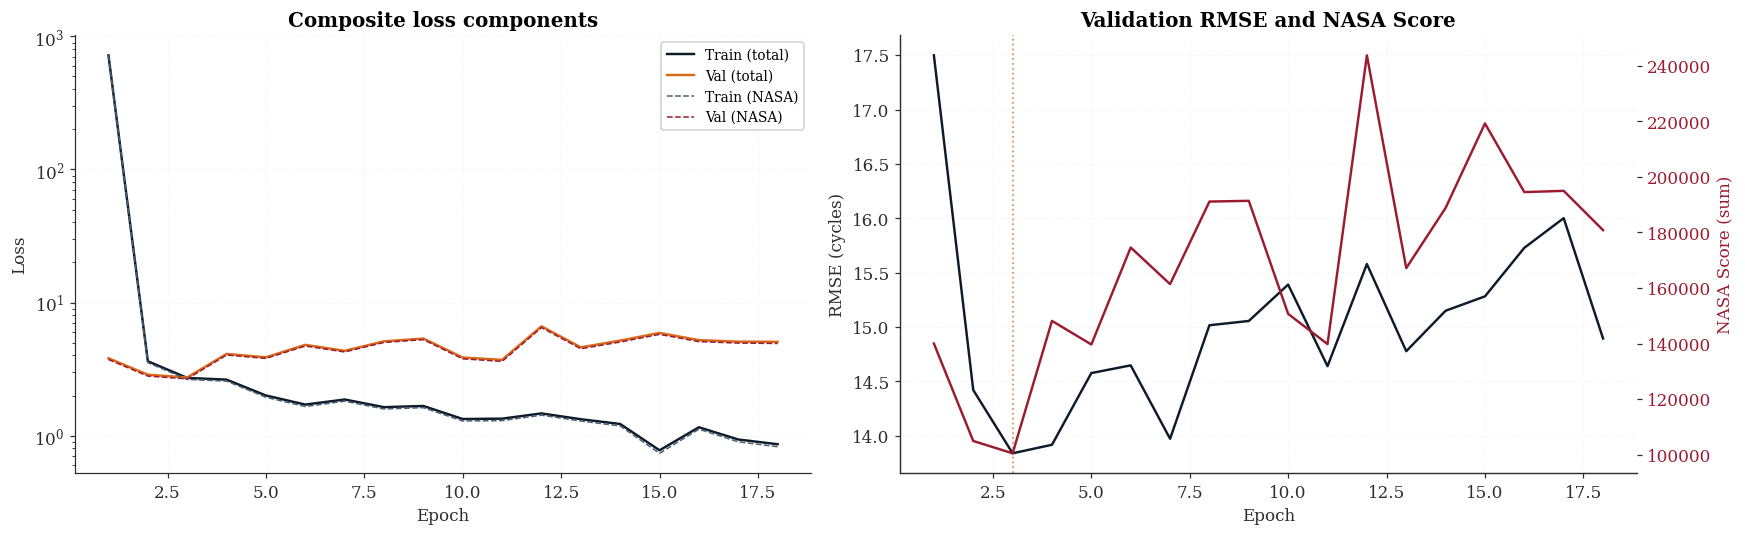

In [17]:
# ============================================================================
# Cell 17 — Visual: Loss Curves and NASA Score / RMSE Over Epochs
# ============================================================================

epochs   = [h["epoch"] for h in history]
tr_total = [h["train"]["loss"] for h in history]
tr_rul   = [h["train"]["loss_rul"] for h in history]
tr_ce    = [h["train"]["loss_ce"] for h in history]
va_total = [h["val"]["loss"] for h in history]
va_rul   = [h["val"]["loss_rul"] for h in history]
va_ce    = [h["val"]["loss_ce"] for h in history]
va_rmse  = [h["val"]["rmse"] for h in history]
va_nasa  = [h["val"]["nasa_score"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs, tr_total, color=FC_DARK_BLUE, linewidth=1.6, label="Train (total)")
axes[0].plot(epochs, va_total, color=FC_ORANGE,    linewidth=1.6, label="Val (total)")
axes[0].plot(epochs, tr_rul,   color=FC_STEEL,     linewidth=1.0, linestyle="--", label="Train (NASA)")
axes[0].plot(epochs, va_rul,   color=FC_DEEP_RED,  linewidth=1.0, linestyle="--", label="Val (NASA)")
axes[0].set_title("Composite loss components")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(linestyle=":", alpha=0.5)

axes[1].plot(epochs, va_rmse, color=FC_DARK_BLUE, linewidth=1.6, label="Val RMSE (cycles)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE (cycles)")
axes[1].grid(linestyle=":", alpha=0.5)
ax2 = axes[1].twinx()
ax2.plot(epochs, va_nasa, color=FC_DEEP_RED, linewidth=1.6, label="Val NASA Score")
ax2.set_ylabel("NASA Score (sum)", color=FC_DEEP_RED)
ax2.tick_params(axis="y", labelcolor=FC_DEEP_RED)
axes[1].axvline(best_epoch, color=FC_ORANGE, linestyle=":", linewidth=1.2, alpha=0.7)
axes[1].set_title("Validation RMSE and NASA Score")
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_3_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()

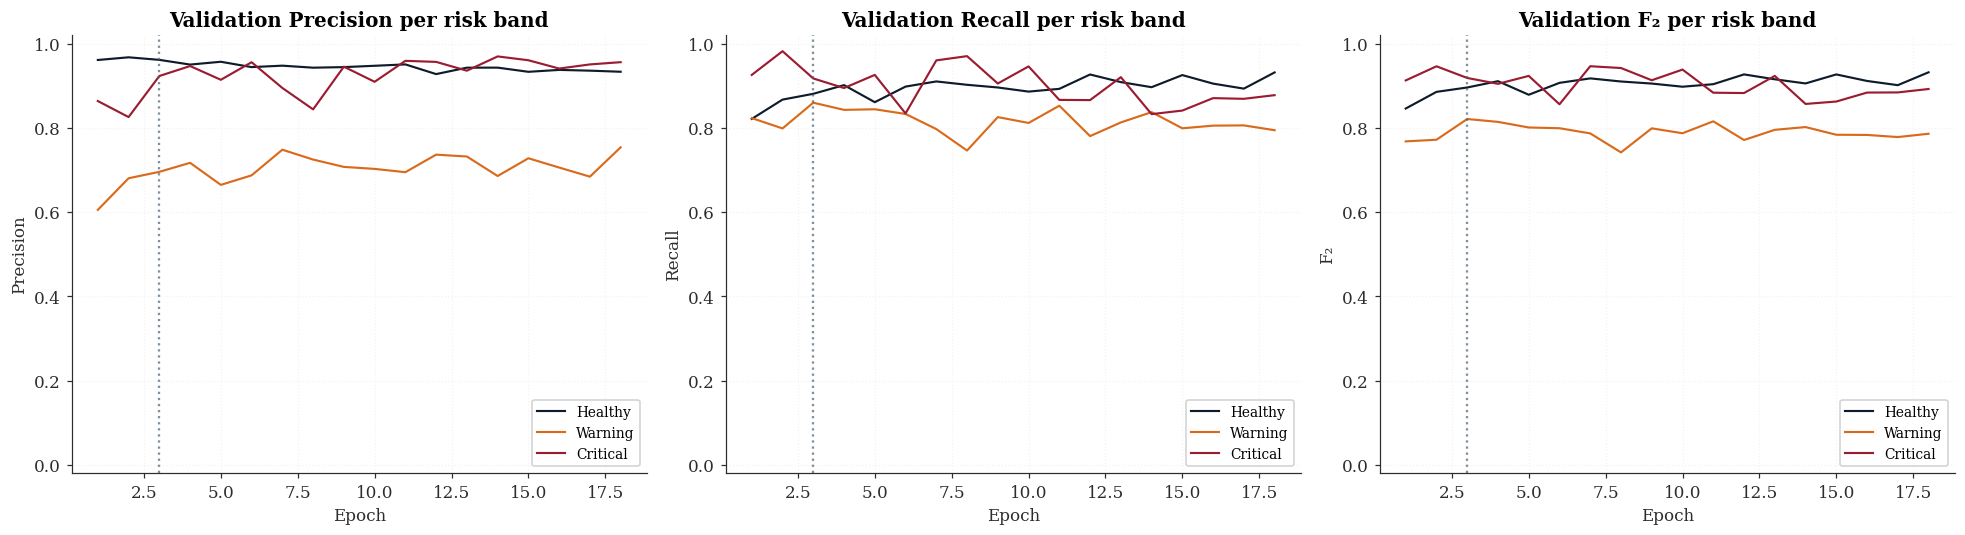

In [18]:
# ============================================================================
# Cell 18 — Visual: Per-Class Precision / Recall / F2 Over Epochs
# ============================================================================

precs = np.array([h["val"]["precision"] for h in history])  # (E, 3)
recs  = np.array([h["val"]["recall"]    for h in history])
f2s   = np.array([h["val"]["f2"]        for h in history])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
band_names = ["Healthy", "Warning", "Critical"]
colors = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED]
for ax, metric, mname in [(axes[0], precs, "Precision"),
                          (axes[1], recs,  "Recall"),
                          (axes[2], f2s,   "F₂")]:
    for c in range(3):
        ax.plot(epochs, metric[:, c], color=colors[c], linewidth=1.4, label=band_names[c])
    ax.axvline(best_epoch, color=FC_STEEL, linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch"); ax.set_ylabel(mname)
    ax.set_title(f"Validation {mname} per risk band")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_3_critical_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Ph-v1.3 Gate

Twelve programmatic checks per v1CLAUDE.md §8 row Ph-v1.3.

In [19]:
# ============================================================================
# Cell 19 — Ph-v1.3 Gate
# ============================================================================

print("=" * 78)
print("  Ph-v1.3 GATE — Stage A Training")
print("=" * 78)

checks = []

# 1. No NaN gradients seen at any point.
checks.append(("No NaN/Inf gradients during training",
               not nan_grad_seen, "no NaN/Inf" if not nan_grad_seen else "NaN/Inf detected"))

# 2. Trained at least one epoch.
checks.append(("At least one epoch completed", len(history) >= 1, f"{len(history)} epochs"))

# 3. Training loss monotonically descended (modulo noise).
#    Use first-vs-best-window comparison: best 10% < first 10%.
window = max(1, len(history) // 10)
first_avg = float(np.mean([h["train"]["loss"] for h in history[:window]]))
last_avg  = float(np.mean([h["train"]["loss"] for h in history[-window:]]))
descended = last_avg < first_avg * 0.9
checks.append(("Training loss descended (last 10% < 90% of first 10%)",
               descended, f"first={first_avg:.4f}  last={last_avg:.4f}"))

# 4. Best epoch achieved better val NASA than initial.
init_val_nasa = history[0]["val"]["nasa_score"] if history else float("inf")
checks.append(("Best val NASA improved on initial",
               best_val_nasa < init_val_nasa,
               f"init={init_val_nasa:.0f}  best={best_val_nasa:.0f}"))

# 5. Critical-class recall non-trivial mid-training.
#    Definition: max recall on Critical class across all epochs > 0.30.
max_critical_recall = float(max(h["val"]["recall"][2] for h in history))
checks.append(("Critical-class recall reached > 0.30",
               max_critical_recall > 0.30, f"max R_C = {max_critical_recall:.3f}"))

# 6. Final val loss finite.
final_loss = history[-1]["val"]["loss"]
checks.append(("Final val loss finite",
               np.isfinite(final_loss), f"{final_loss:.4f}"))

# 7-9. Persisted artefacts.
for fn in ("phase_v1_3_pinet_best.pt", "phase_v1_3_pinet_last.pt", "phase_v1_3_training_history.json"):
    checks.append((f"Persisted: {fn}", (V1_OUT / fn).exists(), "OK"))

# 10. best.pt round-trips.
try:
    sd = torch.load(V1_OUT / "phase_v1_3_pinet_best.pt", map_location="cpu", weights_only=True)
    test_model = PiNet().to("cpu")
    test_model.load_state_dict(sd)
    rt_ok = True
except Exception as e:
    rt_ok = False
checks.append(("Best state-dict round-trips into a fresh PiNet", rt_ok, "OK"))

# 11. Visual artefacts saved.
for fn in ("phase_v1_3_loss_curves.png", "phase_v1_3_critical_metrics.png"):
    checks.append((f"Persisted: {fn}", (V1_OUT / fn).exists(), "OK"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")

n_pass = sum(1 for _, o, _ in checks if o)
print(f"\n  Ph-v1.3 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _, o, _ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _, o, _ in checks), "Ph-v1.3 GATE FAILED"
print("  Ph-v1.3 — proceed to Ph-v1.4 (headline NASA test-set evaluation)")

  Ph-v1.3 GATE — Stage A Training
  [PASS] No NaN/Inf gradients during training                         no NaN/Inf
  [PASS] At least one epoch completed                                 18 epochs
  [PASS] Training loss descended (last 10% < 90% of first 10%)        first=720.6932  last=0.8604
  [PASS] Best val NASA improved on initial                            init=140011  best=100488
  [PASS] Critical-class recall reached > 0.30                         max R_C = 0.983
  [PASS] Final val loss finite                                        5.0663
  [PASS] Persisted: phase_v1_3_pinet_best.pt                          OK
  [PASS] Persisted: phase_v1_3_pinet_last.pt                          OK
  [PASS] Persisted: phase_v1_3_training_history.json                  OK
  [PASS] Best state-dict round-trips into a fresh PiNet               OK
  [PASS] Persisted: phase_v1_3_loss_curves.png                        OK
  [PASS] Persisted: phase_v1_3_critical_metrics.png                   OK

  Ph-v1.3 

---

## Summary

### Ph-v1.3 outputs (under `v1/outputs/`)
- `phase_v1_3_pinet_best.pt` — best-epoch state-dict (lowest Internal Val NASA score)
- `phase_v1_3_pinet_last.pt` — final-epoch state-dict (for resume)
- `phase_v1_3_training_history.json` — per-epoch metrics
- `phase_v1_3_loss_curves.png` — training and validation loss curves
- `phase_v1_3_critical_metrics.png` — per-class precision / recall / F₂ trajectories

### Headline numbers
- Best-epoch validation NASA score, RMSE, Critical-band F₂
- Critical-class recall trajectory (the safety metric)
- Wall-clock time per epoch and total

### Next notebook
`04_Headline_Evaluation.ipynb` — Ph-v1.4 NASA test-set evaluation: PiNet
vs the v0 XGBoost baseline (RMSE 14.85, NASA 4,336.3, Critical-band F₂
0.9339). The Ph-v1.4 gate fires the Critical-Recall Safety Gate from
v1CLAUDE.md §9.